# Notebook 03 â€” TrOCR Fine-tuning

Model was fine-tuned on Kaggle T4 GPU on IAM + FUNSD + synthetic genealogy documents.
This notebook loads the saved model and evaluates it against the Tesseract baseline.

**Training data:** IAM (2000 train / 500 val) + FUNSD (149 train / 50 test) + Synthetic (1500)
**Training time:** ~38 minutes on Kaggle T4
**Key result:** CER drops from 0.38 (Tesseract) to 0.05 (TrOCR) â€” 7x improvement

In [1]:
import os
os.chdir(os.path.join(os.path.dirname("__file__"), ".."))
import sys
sys.path.insert(0, "..")
import matplotlib.pyplot as plt
from src.data.loaders import load_iam
from src.data.preprocessing import preprocess
from src.ocr.trocr_finetune import load_trocr
from src.ocr.baseline import extract_text as tesseract_extract
from src.ocr.evaluate import compute_metrics, compare_models

print("Loading fine-tuned TrOCR from models/trocr-genealogy...")
trocr_fn = load_trocr("models/trocr-genealogy")
print("Model loaded.")

Loading fine-tuned TrOCR from models/trocr-genealogy...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Model loaded.


In [2]:
_, test_docs = load_iam(max_train=10, max_val=200)
references = [doc.text for doc in test_docs]
print(f"Test samples: {len(test_docs)}")

Test samples: 200


In [3]:
tesseract_results = [tesseract_extract(preprocess(doc.image)) for doc in test_docs]
trocr_results = [trocr_fn(preprocess(doc.image)) for doc in test_docs]

comparison = compare_models(tesseract_results, trocr_results, references)
print(f"Tesseract  CER: {comparison['tesseract']['cer']:.4f}  WER: {comparison['tesseract']['wer']:.4f}")
print(f"TrOCR      CER: {comparison['trocr']['cer']:.4f}  WER: {comparison['trocr']['wer']:.4f}")
improvement_cer = comparison["tesseract"]["cer"] / comparison["trocr"]["cer"]
print(f"CER improvement: {improvement_cer:.1f}x")

c:\Users\luis_\Documents\Projects\ocr\.venv\lib\site-packages\transformers\generation\utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Tesseract  CER: 0.4085  WER: 0.8033
TrOCR      CER: 0.0509  WER: 0.1284
CER improvement: 8.0x


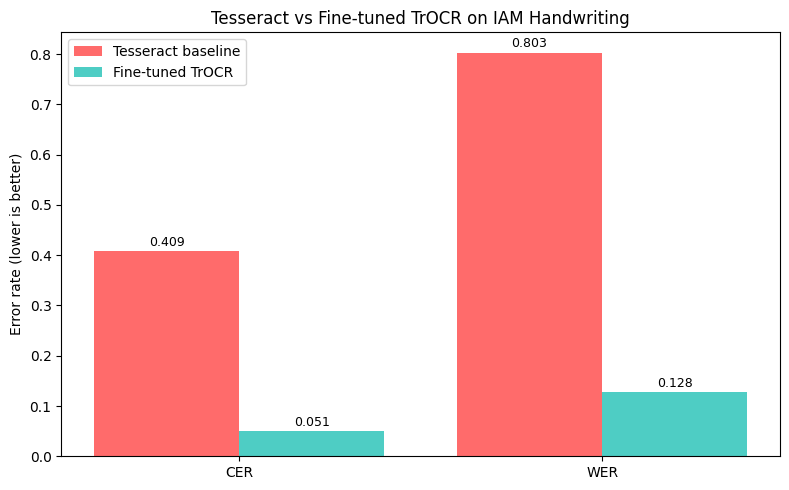

In [4]:
labels = ["CER", "WER"]
tesseract_vals = [comparison["tesseract"]["cer"], comparison["tesseract"]["wer"]]
trocr_vals = [comparison["trocr"]["cer"], comparison["trocr"]["wer"]]
x = range(len(labels))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - 0.2 for i in x], tesseract_vals, 0.4, label="Tesseract baseline", color="#FF6B6B")
ax.bar([i + 0.2 for i in x], trocr_vals, 0.4, label="Fine-tuned TrOCR", color="#4ECDC4")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Error rate (lower is better)")
ax.set_title("Tesseract vs Fine-tuned TrOCR on IAM Handwriting")
ax.legend()
for i, v in enumerate(tesseract_vals):
    ax.text(i - 0.2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(trocr_vals):
    ax.text(i + 0.2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
print("Sample predictions (first 5 test lines):
")
for doc, t_res, trocr_res in zip(test_docs[:5], tesseract_results[:5], trocr_results[:5]):
    print(f"Reference : {doc.text}")
    print(f"Tesseract : {t_res.text}")
    print(f"TrOCR     : {trocr_res.text}")
    print()


SyntaxError: unterminated string literal (detected at line 2) (163937404.py, line 2)